In [11]:
import os
import re
import pickle
import copy
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pymoo.indicators.igd import IGD
from optimization.lhs import LHS

os.environ["CUDA_VISIBLE_DEVICES"]= "-1"

# Training dataset

In [13]:
def path_to_num(string):
    res = re.findall("structure_\d+_", string)[0]
    res = re.findall("\d+", res)[0]
    return int(res)


root = r"D:\inception_dataset\train"
header_names = ["structure_num", "young_module", "fem_volume_fraction"]

normal0_ym = pd.read_csv(os.path.join(root, "64_normal_0_young_modules.csv"), names=header_names)
normal15_ym = pd.read_csv(os.path.join(root, "64_normal_1.5_young_modules.csv"), names=header_names)
spheresRVE_ym = pd.read_csv(os.path.join(root, "64_spheresRVE_young_modules.csv"), names=header_names)
uniform05_ym = pd.read_csv(os.path.join(root, "64_uniform_0.5_young_modules.csv"), names=header_names)
uniform1_ym = pd.read_csv(os.path.join(root, "64_uniform_1_young_modules.csv"), names=header_names)

normal0_info = pd.read_csv(os.path.join(root, "info_64_normal_0.csv"))
normal15_info = pd.read_csv(os.path.join(root, "info_64_normal_1.5.csv"))
spheresRVE_info = pd.read_csv(os.path.join(root, "info_64_spheresRVE.csv"))
uniform05_info = pd.read_csv(os.path.join(root, "info_64_uniform_0.5.csv"))
uniform1_info = pd.read_csv(os.path.join(root, "info_64_uniform_1.csv"))

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\inception_dataset\\train/64_normal_0_young_modules.csv'

In [101]:
normal0_info["num"] = normal0_info.index.values
normal15_info["num"] = normal15_info.index.values
uniform05_info["num"] = uniform05_info.index.values
uniform1_info["num"] = uniform1_info.index.values

normal0_ym["structure_num"] = normal0_ym["structure_num"].apply(lambda x: path_to_num(x))
normal15_ym["structure_num"] = normal15_ym["structure_num"].apply(lambda x: path_to_num(x))
spheresRVE_ym["structure_num"] = spheresRVE_ym["structure_num"].apply(lambda x: path_to_num(x))
uniform05_ym["structure_num"] = uniform05_ym["structure_num"].apply(lambda x: path_to_num(x))
uniform1_ym["structure_num"] = uniform1_ym["structure_num"].apply(lambda x: path_to_num(x))

normal0_ym["class"] = "Open-cell, $N(0,1)$"
normal15_ym["class"] = "Open-cell, $N(1.5,1)$"
spheresRVE_ym["class"] = "Closed-cell"
uniform05_ym["class"] = "Open-cell, $U(-0.5,0.5)$"
uniform1_ym["class"] = "Open-cell, $U(-1,1)$"

normal0_info = normal0_info.merge(normal0_ym, how="left", left_on="num", right_on="structure_num")
normal15_info = normal15_info.merge(normal15_ym, how="left", left_on="num", right_on="structure_num")
spheresRVE_info = spheresRVE_info.merge(spheresRVE_ym, how="left", left_on="idx", right_on="structure_num")
uniform05_info = uniform05_info.merge(uniform05_ym, how="left", left_on="num", right_on="structure_num")
uniform1_info = uniform1_info.merge(uniform1_ym, how="left", left_on="num", right_on="structure_num")

train_ds_info = pd.concat([normal0_info, normal15_info, spheresRVE_info, uniform05_info, uniform1_info])

In [102]:
train_ds_info.dropna(subset="young_module", inplace=True)
train_ds_info.reset_index(drop=True, inplace=True)
train_ds_info["volume_fraction_error"] = np.abs(1 - train_ds_info["volume_fraction"] / train_ds_info["fem_volume_fraction"]) * 100

In [5]:
dpi = 100
font_size = 10
plt_style = "seaborn-bright"
plt.style.use(plt_style)
sns.set_style("white")
plt.rcParams.update({"font.size": font_size})

/tmp/ipykernel_3706284/2806246402.py:4: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use(plt_style)


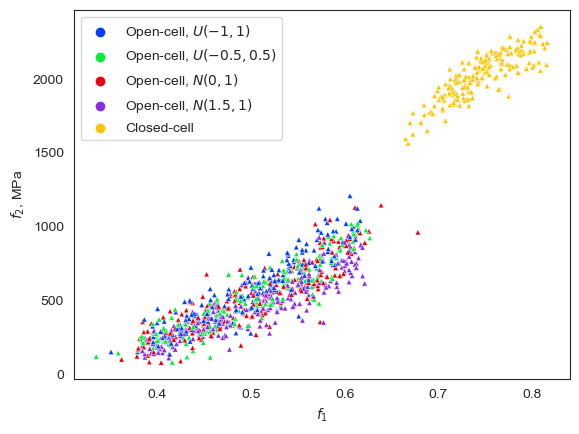

In [104]:
fig, ax = plt.subplots(dpi=dpi)
sns.scatterplot(
    ax=ax,
    data=train_ds_info.sample(1000, random_state=1),
    x="volume_fraction",
    y="young_module",
    hue="class",
    s=15.0,
    marker="^",
)
ax.set_xlabel("$f_1$")
ax.set_ylabel("$f_2$, MPa") # MPa because the model size in millimeters
ax.legend(title="")

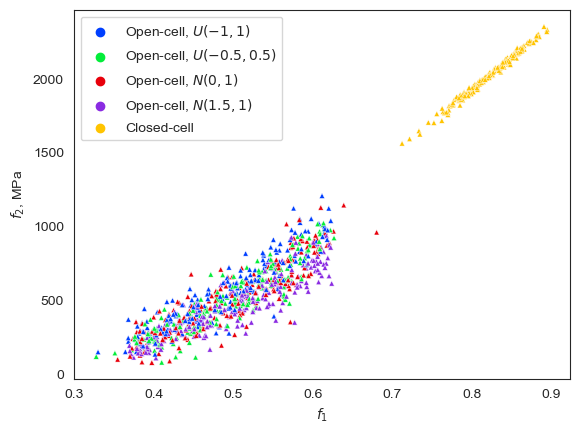

In [105]:
fig, ax = plt.subplots(dpi=dpi)
sns.scatterplot(
    ax=ax,
    data=train_ds_info.sample(1000, random_state=1),
    x="fem_volume_fraction",
    y="young_module",
    hue="class",
    s=15.0,
    marker="^",
)
ax.set_xlabel("$f_1$")
ax.set_ylabel("$f_2$, MPa") # MPa because the model size in millimeters
ax.legend(title="")

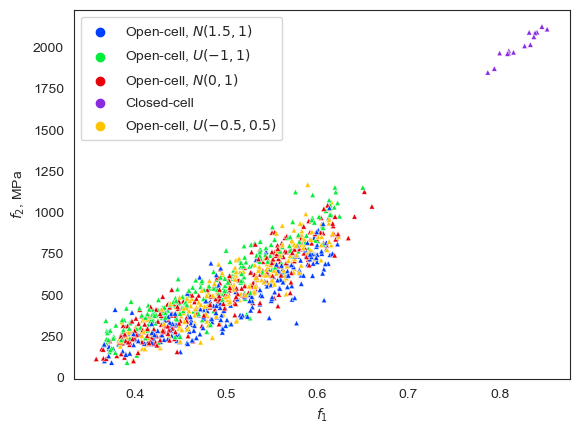

In [106]:
fig, ax = plt.subplots(dpi=dpi)
sns.scatterplot(
    ax=ax,
    data=train_ds_info[train_ds_info["volume_fraction_error"] < 5].sample(1000, random_state=2),
    x="fem_volume_fraction",
    y="young_module",
    hue="class",
    s=15.0,
    marker="^",
)
ax.set_xlabel("$f_1$")
ax.set_ylabel("$f_2$, MPa") # MPa because the model size in millimeters
ax.legend(title="")

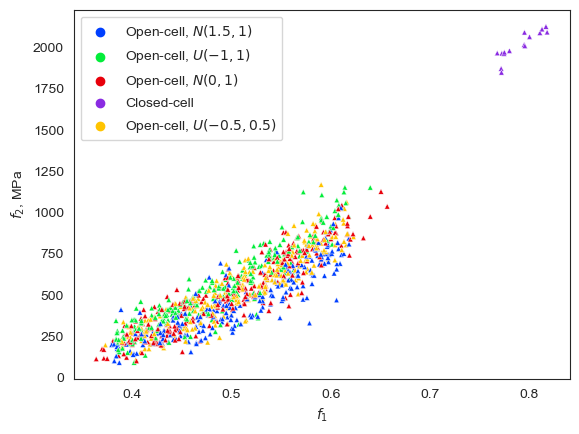

In [107]:
fig, ax = plt.subplots(dpi=dpi)
sns.scatterplot(
    ax=ax,
    data=train_ds_info[train_ds_info["volume_fraction_error"] < 5].sample(1000, random_state=2),
    x="volume_fraction",
    y="young_module",
    hue="class",
    s=15.0,
    marker="^",
    legend="full"
)
ax.set_xlabel("$f_1$")
ax.set_ylabel("$f_2$, MPa") # MPa because the model size in millimeters
ax.legend(title="")

# Optimization result

In [2]:
dpi = 100
font_size = 10
plt_style = "seaborn-v0_8-bright"
plt.style.use(plt_style)
sns.set_style("white")
plt.rcParams.update({"font.size": font_size})

In [4]:
res_name = "024000_141_w_64"
with open(r"../optimization/results/" + res_name, "rb") as f:
    optimization_res = pickle.load(f)

optimization_ds = pd.DataFrame({"volume_fraction": optimization_res[1][:, 0], "young_module": -optimization_res[1][:, 1]})
optimization_ds["class"] = res_name

with open(r"../optimization/history/" + res_name, "rb") as f:
    optimization_hist = pickle.load(f)

### Сравнение обучающего набора и BEST CHECKPOINT

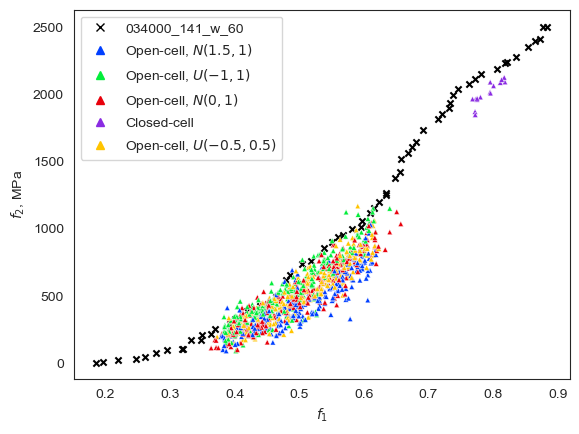

In [109]:
fig, ax = plt.subplots(dpi=dpi)

ax.scatter(
    x=optimization_ds["volume_fraction"],
    y=optimization_ds["young_module"],
    s=20,
    c="black",
    marker="x",
    label=res_name
)

sns.scatterplot(
    ax=ax,
    data=train_ds_info[train_ds_info["volume_fraction_error"] < 5].sample(1000, random_state=2),
    x="volume_fraction",
    y="young_module",
    hue="class",
    s=15,
    marker="^",
)

ax.set_xlabel("$f_1$")
ax.set_ylabel("$f_2$, MPa") # MPa because the model size in millimeters

letter_set1 = {res_name}
letter_set2 = pd.unique(train_ds_info["class"])

marker_set1 = "x"
marker_set2 = "^"

marker_for_letter = {
    **{letter: marker_set1 for letter in letter_set1},
    **{letter: marker_set2 for letter in letter_set2}
}

handles, labels = ax.get_legend_handles_labels()
handles = [
    Line2D([], [], color=h.get_facecolor(), linestyle='', marker=marker_for_letter[l])
    for h, l in zip(handles, labels)
]

ax.legend(handles, labels)

### Сравнение n_gen = 100 и n_gen = 20

In [9]:
res_name = "024000_141_w_100ngen_64"
with open(r"../optimization/results/" + res_name, "rb") as f:
    optimization_res2 = pickle.load(f)

optimization_ds2 = pd.DataFrame({"volume_fraction": optimization_res2[1][:, 0], "young_module": -optimization_res2[1][:, 1]})
optimization_ds2["class"] = res_name

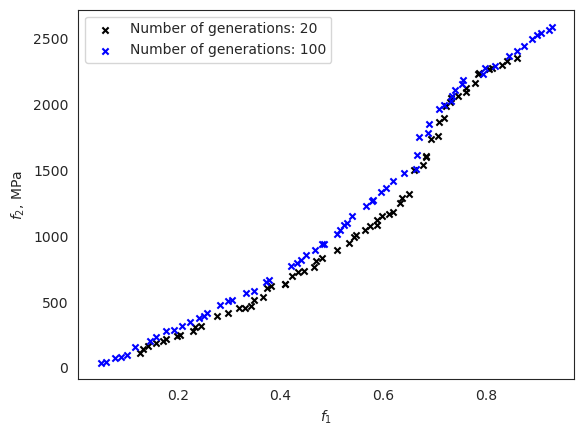

In [10]:
fig, ax = plt.subplots(dpi=dpi)

ax.scatter(
    x=optimization_ds["volume_fraction"],
    y=optimization_ds["young_module"],
    s=20,
    c="black",
    marker="x",
    label="Number of generations: 20"
)

ax.scatter(
    x=optimization_ds2["volume_fraction"],
    y=optimization_ds2["young_module"],
    s=20,
    c="blue",
    marker="x",
    label="Number of generations: 100"
)

ax.set_xlabel("$f_1$")
ax.set_ylabel("$f_2$, MPa") # MPa because the model size in millimeters
ax.legend()

In [46]:
target_pf

array([[4.93659973e-02, 3.93019638e+01],
       [9.28405762e-01, 2.58595066e+03],
       [6.88751221e-01, 1.84720913e+03],
       [7.09442139e-01, 1.95740251e+03],
       [8.18950653e-01, 2.29034879e+03],
       [8.46134186e-01, 2.36538770e+03],
       [6.69929504e-01, 1.75201089e+03],
       [6.40377045e-01, 1.47438322e+03],
       [6.19266510e-01, 1.41311140e+03],
       [2.81955719e-01, 4.72922952e+02],
       [7.94441223e-01, 2.22831878e+03],
       [7.56305695e-01, 2.17704972e+03],
       [5.10238647e-01, 1.01564430e+03],
       [3.32309723e-01, 5.69470540e+02],
       [6.66553497e-01, 1.61086382e+03],
       [2.56324768e-01, 4.18195010e+02],
       [4.84638214e-01, 9.39077561e+02],
       [3.05011749e-01, 5.14160422e+02],
       [1.17099762e-01, 1.54211424e+02],
       [8.89934540e-01, 2.49099367e+03],
       [5.95821381e-01, 1.33111011e+03],
       [1.00437164e-01, 9.59898907e+01],
       [2.22930908e-01, 3.49324326e+02],
       [6.04682922e-01, 1.36285407e+03],
       [6.866798

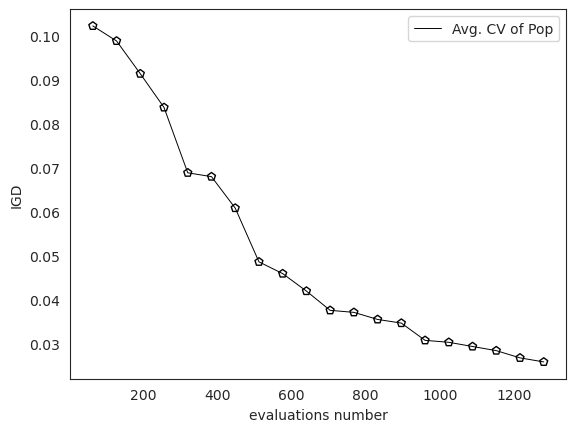

In [51]:
n_evals = optimization_hist["n_evals"]
hist_F = optimization_hist["hist_F"]
hist_cv = optimization_hist["hist_cv"]
hist_cv_avg = optimization_hist["hist_cv_avg"]

target_pf = optimization_ds2[["volume_fraction", "young_module"]].to_numpy()
target_pf[:, 1] = -target_pf[:, 1]
metric = IGD(target_pf, zero_to_one=True)


igd = [metric.do(_F) for _F in hist_F]

plt.plot(n_evals, igd,  color='black', lw=0.7, label="Avg. CV of Pop")
plt.scatter(n_evals, igd,  facecolor="none", edgecolor='black', marker="p")
plt.xlabel("evaluations number")
plt.ylabel("IGD")
plt.legend()
plt.show()


In [22]:
k = np.where(np.array(hist_cv) <= 0.0)[0].min()
print(f"At least one feasible solution in Generation {k} after {n_evals[k]} evaluations.")

At least one feasible solution in Generation 0 after 64 evaluations.


Whole population feasible in Generation 0 after 64 evaluations.


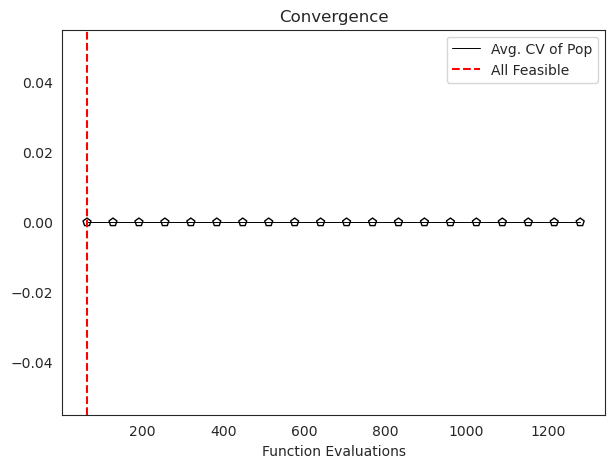

In [25]:
# replace this line by `hist_cv` if you like to analyze the least feasible optimal solution and not the population
vals = hist_cv_avg

k = np.where(np.array(vals) <= 0.0)[0].min()
print(f"Whole population feasible in Generation {k} after {n_evals[k]} evaluations.")

plt.figure(figsize=(7, 5))
plt.plot(n_evals, vals,  color='black', lw=0.7, label="Avg. CV of Pop")
plt.scatter(n_evals, vals,  facecolor="none", edgecolor='black', marker="p")
plt.axvline(n_evals[k], color="red", label="All Feasible", linestyle="--")
plt.title("Convergence")
plt.xlabel("Function Evaluations")
plt.legend()
plt.show()

### Сравнение пространств Z и W

In [185]:
res_name = "024000_141_z_64"
with open(r"../optimization/results/" + res_name, "rb") as f:
    optimization_res2 = pickle.load(f)

optimization_ds2 = pd.DataFrame({"volume_fraction": optimization_res2[1][:, 0], "young_module": -optimization_res2[1][:, 1]})
optimization_ds2["class"] = res_name

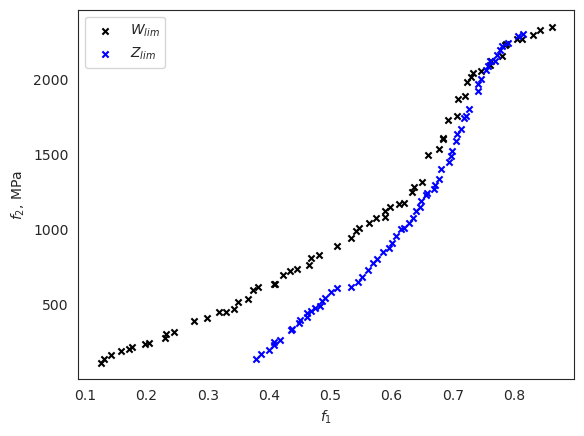

In [186]:
fig, ax = plt.subplots(dpi=dpi)

ax.scatter(
    x=optimization_ds["volume_fraction"],
    y=optimization_ds["young_module"],
    s=20,
    c="black",
    marker="x",
    label="$W_{lim}$"
)

ax.scatter(
    x=optimization_ds2["volume_fraction"],
    y=optimization_ds2["young_module"],
    s=20,
    c="blue",
    marker="x",
    label="$Z_{lim}$"
)

ax.set_xlabel("$f_1$")
ax.set_ylabel("$f_2$, MPa") # MPa because the model size in millimeters
ax.legend()

### Сравнение диапазонов lover bound и upper bound

In [65]:
res_name = "024000_141_w_0.75_64"
with open(r"../optimization/results/" + res_name, "rb") as f:
    optimization_res2 = pickle.load(f)

optimization_ds2 = pd.DataFrame({"volume_fraction": optimization_res2[1][:, 0], "young_module": -optimization_res2[1][:, 1]})
optimization_ds2["class"] = res_name

res_name = "024000_141_w_1.25_64"
with open(r"../optimization/results/" + res_name, "rb") as f:
    optimization_res3 = pickle.load(f)

optimization_ds3 = pd.DataFrame({"volume_fraction": optimization_res3[1][:, 0], "young_module": -optimization_res3[1][:, 1]})
optimization_ds3["class"] = res_name

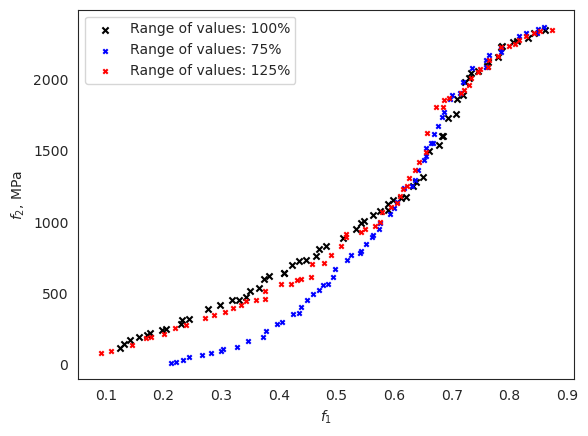

In [66]:
fig, ax = plt.subplots(dpi=dpi)

ax.scatter(
    x=optimization_ds["volume_fraction"],
    y=optimization_ds["young_module"],
    s=20,
    c="black",
    marker="x",
    label="Range of values: 100%"
)

ax.scatter(
    x=optimization_ds2["volume_fraction"],
    y=optimization_ds2["young_module"],
    s=10,
    c="blue",
    marker="x",
    label="Range of values: 75%"
)


ax.scatter(
    x=optimization_ds3["volume_fraction"],
    y=optimization_ds3["young_module"],
    s=10,
    c="red",
    marker="x",
    label="Range of values: 125%"
)

ax.set_xlabel("$f_1$")
ax.set_ylabel("$f_2$, MPa") # MPa because the model size in millimeters
ax.legend()

### Сравнение гиперпараметров NSGA-II

In [67]:
res_name = "024000_141_w_nc2_64"
with open(r"../optimization/results/" + res_name, "rb") as f:
    optimization_res2 = pickle.load(f)

optimization_ds2 = pd.DataFrame({"volume_fraction": optimization_res2[1][:, 0], "young_module": -optimization_res2[1][:, 1]})
optimization_ds2["class"] = res_name

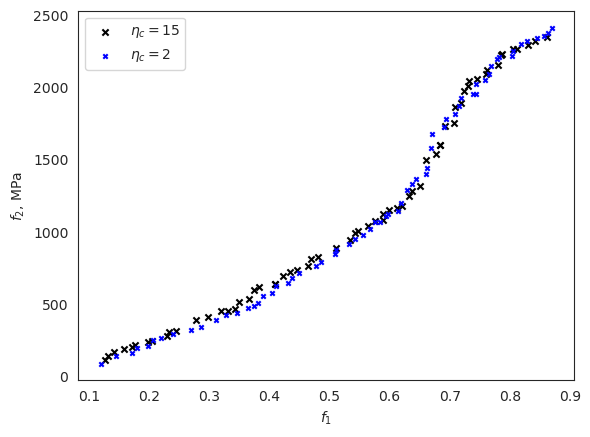

In [68]:
fig, ax = plt.subplots(dpi=dpi)

ax.scatter(
    x=optimization_ds["volume_fraction"],
    y=optimization_ds["young_module"],
    s=20,
    c="black",
    marker="x",
    label="$\eta_c=15$"
)

ax.scatter(
    x=optimization_ds2["volume_fraction"],
    y=optimization_ds2["young_module"],
    s=10,
    c="blue",
    marker="x",
    label="$\eta_c=2$"
)

ax.set_xlabel("$f_1$")
ax.set_ylabel("$f_2$, MPa") # MPa because the model size in millimeters
ax.legend()

In [69]:
hist_res = optimization_res.history

AttributeError: 'list' object has no attribute 'history'

### Сравнение архитектур по FID

In [63]:
res_name = "034000_141_w_64"
with open(r"../optimization/results/" + res_name, "rb") as f:
    optimization_res2 = pickle.load(f)

optimization_ds2 = pd.DataFrame({"volume_fraction": optimization_res2[1][:, 0], "young_module": -optimization_res2[1][:, 1]})
optimization_ds2["class"] = res_name

res_name = "043000_141_w_64"
with open(r"../optimization/results/" + res_name, "rb") as f:
    optimization_res3 = pickle.load(f)

optimization_ds3 = pd.DataFrame({"volume_fraction": optimization_res3[1][:, 0], "young_module": -optimization_res3[1][:, 1]})
optimization_ds3["class"] = res_name

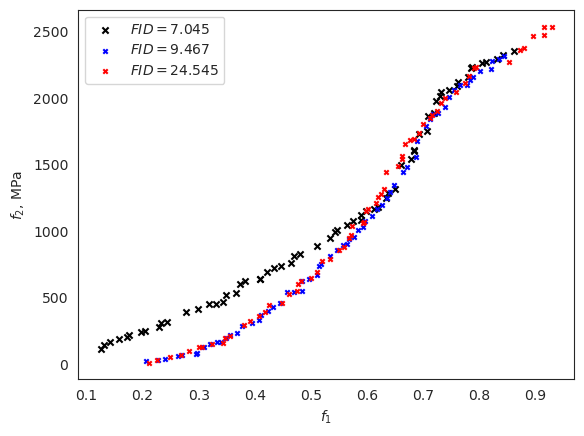

In [64]:
fig, ax = plt.subplots(dpi=dpi)

ax.scatter(
    x=optimization_ds["volume_fraction"],
    y=optimization_ds["young_module"],
    s=20,
    c="black",
    marker="x",
    label="$FID=7.045$"
)

ax.scatter(
    x=optimization_ds2["volume_fraction"],
    y=optimization_ds2["young_module"],
    s=10,
    c="blue",
    marker="x",
    label="$FID=9.467$"
)


ax.scatter(
    x=optimization_ds3["volume_fraction"],
    y=optimization_ds3["young_module"],
    s=10,
    c="red",
    marker="x",
    label="$FID=24.545$"
)

ax.set_xlabel("$f_1$")
ax.set_ylabel("$f_2$, MPa") # MPa because the model size in millimeters
ax.legend()

In [180]:
from pymoo.indicators.hv import Hypervolume

test = np.array([optimization_res[1][:, 0], -optimization_res[1][:, 1]]).transpose()
approx_ideal = test.min(axis=0)
approx_nadir = test.max(axis=0)
metric = Hypervolume(ref_point=np.array([0.3, 3000]), zero_to_one=True, ideal=approx_ideal, nadir=approx_nadir)
metric.do(test)

0.306277698958222

In [151]:
approx_nadir

array([8.61385345e-01, 2.35066818e+03])

In [122]:
np.array([optimization_res[1][:, 0], optimization_res[1][:, 1]]).reshape((64, 2)).shape

(64, 2)

In [88]:
optimization_res[1].shape

(64, 2)

# UMAP

In [47]:
import umap
import tensorflow as tf
from umap.parametric_umap import ParametricUMAP

ModuleNotFoundError: No module named 'umap'

In [14]:
x_opt = copy.deepcopy(optimization_res[0])

In [15]:
x_opt.shape

(60, 128)

In [16]:
tf.random.set_seed(1)
np.random.seed(1)

embedder = ParametricUMAP(
    n_neighbors=15,
    min_dist=0.0,
    n_components=2,
    metric='euclidean', # можно 'manhattan'
    random_state=1,
    verbose=True
)
embedder.fit(x_opt)

C:\Users\Evgeniy\Anaconda3\envs\tf-torch\lib\site-packages\umap\parametric_umap.py:148: UserWarning: tensorflow_probability not installed or incompatible to current                 tensorflow installation. Setting global_correlation_loss_weight to zero.
  warn(


ParametricUMAP(optimizer=<keras.optimizers.optimizer_v2.adam.Adam object at 0x000002379240A790>)
Tue Jun  6 14:09:56 2023 Construct fuzzy simplicial set
Tue Jun  6 14:09:56 2023 Finding Nearest Neighbors
Tue Jun  6 14:09:57 2023 Finished Nearest Neighbor Search
Tue Jun  6 14:09:59 2023 Construct embedding
Epoch 1/10
317/317 [==============================] - 1s 1ms/step - loss: 0.6556
Epoch 2/10
317/317 [==============================] - 0s 1ms/step - loss: 0.5141
Epoch 3/10
317/317 [==============================] - 0s 1ms/step - loss: 0.5069
Epoch 4/10
317/317 [==============================] - 0s 1ms/step - loss: 0.5002
Epoch 5/10
317/317 [==============================] - 0s 1ms/step - loss: 0.4966
Epoch 6/10
317/317 [==============================] - 0s 1ms/step - loss: 0.4915
Epoch 7/10
317/317 [==============================] - 0s 1ms/step - loss: 0.4912
Epoch 8/10
317/317 [==============================] - 0s 1ms/step - loss: 0.4947
Epoch 9/10
317/317 [=========================

ParametricUMAP(batch_size=60, dims=[128], encoder=<keras.engine.sequential.Sequential object at 0x000002379DB7E5E0>, optimizer=<keras.optimizers.optimizer_v2.adam.Adam object at 0x000002379240A790>)

In [17]:
umap_embedding = embedder.transform(x_opt)

1/1 [==============================] - 0s 11ms/step


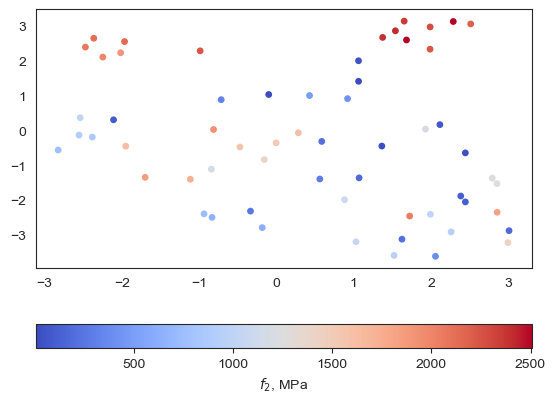

In [18]:
# Интересно взять точку с кластера, построить микроструктуру и сравнить их с другими кластерами
# Выдвигаю гипотезу, что 
fig, ax = plt.subplots(dpi=dpi)

img = ax.scatter(
    umap_embedding[:, 0],
    umap_embedding[:, 1],
    c=optimization_ds["young_module"],
    cmap="coolwarm",
    s=15
)

fig.colorbar(img, ax=ax, label="$f_2$, MPa", orientation="horizontal")

In [19]:
np.argsort(-optimization_res[1][:, 1])[44]

42

Text(0, 0.5, '$f_2$, MPa')

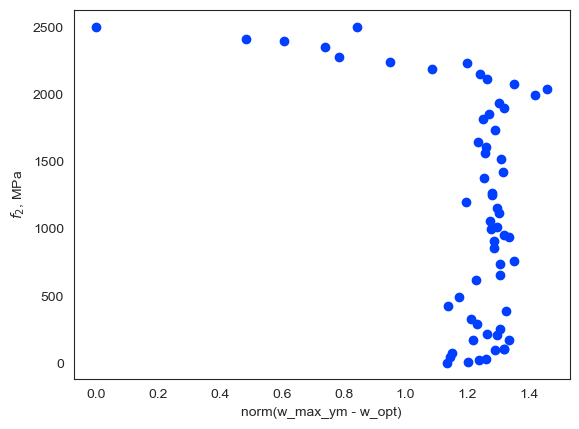

In [20]:
"""
Нужно построить график зависимости нормы (или cosine sim) кодировок в W между самой "прочной"
микроструктурой и всех остальных, а также между самой "слабой" и всех остальных

Сделать то же самое для пространства Z и сравнить графики

Где будет более линейный график, там "структура" пространства лучше (но вообще не факт)
"""

max_ym_idx = np.argmin(optimization_res[1], axis=0)[1]
#x = [np.linalg.norm(x_opt[max_ym_idx] - sample) for sample in x_opt]
x = [np.linalg.norm(x_opt[max_ym_idx] - sample) for sample in x_opt]
y = -optimization_res[1][:, 1]

fig, ax = plt.subplots(dpi=dpi)
ax.scatter(x, y)
ax.set_xlabel("norm(w_max_ym - w_opt)")
ax.set_ylabel("$f_2$, MPa") # MPa because the model size in millimeters

In [27]:
# Взять кластер, где находятся самые "прочные" микроструктуры
# И сравнить его кодировку в W с x_opt[idx], где idx - индекс самой "прочной" микроструктуры
idx = 36
idxs = umap_embedding[:, 1] > 0
samples = x_opt[idxs]
for sample in samples:
    print(np.linalg.norm(x_opt[idx] - sample))

1.6239586622948567
1.4955777289333112
1.4415914488621082
1.1794303348698578
1.0869785923447364
1.5533240843786662
1.0920867828594032
1.24657642324558
1.0017588616863964
1.44816701955558
1.5586183180620468
1.2337507387856081
0.5642930994461581
1.626010465551485
1.3296032944032878
1.3765104199953682
1.6377628821803685
1.5202042646299276
0.0
1.301599835838457
1.3983217794557425
1.3900293058152617
1.5158629358430762
1.7208239569267272
1.1817714867169327
1.3609804151725329
1.3716611959729443
1.720944888369681
1.4992791687540958
1.4045188741964285
1.1584699680573374
1.1298394060320365
1.3751328554236535
1.176241139624941
1.5286095523989056
1.4333316158938036
1.3177928235961547
1.4608860773625645
1.5882684498522248
1.4241217998689581
1.193841312816631


# Microstructure visualizaton

In [21]:
import torch 
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from torch import nn
from training_loop import data_plot, generate_noise, mixing_regularization
from network import MappingNetwork, Generator, StyleBlock

In [22]:
def generate(net_M, net_G, var, var_shapes, opt_space, block_zero_noise=None):
    n_blocks = net_G.n_blocks
    var = np.expand_dims(var, 0)
    device = next(net_G.parameters()).device

    with torch.no_grad():
        if opt_space == "w+noise":
            zero_noise = generate_noise(1, n_blocks, blocks_zero_noise=[i for i in range(n_blocks)])
            zero_noise = [zero_noise[i].to(device) for i in blocks_zero_noise]
            var = torch.from_numpy(var).to(device=device, dtype=torch.float32)
            w_noise = decompose_var(var, var_shapes)
            w, noise = w_noise[0], w_noise[1:] + zero_noise
            w = mixing_regularization([w], n_blocks)
        if opt_space == "w":
            noise = generate_noise(1, n_blocks, device=device, blocks_zero_noise=[i for i in range(n_blocks)])
            w = [torch.from_numpy(var).to(device=device, dtype=torch.float32)]
            w = mixing_regularization(w, n_blocks)
        if opt_space == "z":
            noise = generate_noise(1, n_blocks, device=device, blocks_zero_noise=[i for i in range(n_blocks)])
            z = [torch.from_numpy(var).to(device=device, dtype=torch.float32)]
            w = [net_M(z_i) for z_i in z]
            w = mixing_regularization(w, n_blocks)

        x = net_G(w, noise)
        x = torch.where(x >= 0, 1., -1.) * 0.5 + 0.5
        x = x.cpu().numpy()
        data_plot(x[0, 0])
        plt.show()

In [70]:
batch_size = 100
d_latent = 64
n_layers = 4
lr_multiplier = 0.01
log_resolution = 6
n_features = 16
max_features = 64
activation = nn.Tanh()

net_M = MappingNetwork(d_latent, n_layers, lr_multiplier).eval()
net_G = Generator(log_resolution, d_latent, n_features, max_features, activation=activation).eval()

ckpt = "042000_133"
ckpt_path = r"../checkpoint/" + ckpt + ".pt"

checkpoint = torch.load(ckpt_path, map_location=torch.device("cpu"))
net_M.load_state_dict(checkpoint["net_M_ema"])
net_G.load_state_dict(checkpoint["net_G_ema"])

C:\Users\Evgeniy\Jupyter\Work\materials-design\network.py:161: UserWarning:

Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at  C:\cb\pytorch_1000000000000\work\torch\csrc\utils\tensor_new.cpp:204.)



<All keys matched successfully>

In [49]:
fig = go.Figure()

temp = train_ds_info[train_ds_info["volume_fraction_error"] < 5].sample(1000, random_state=2)
x = temp["volume_fraction"]
y = temp["young_module"]
fig.add_trace(
    go.Scatter(
        x=x,
        y=y,
        mode="markers",
        marker_symbol="triangle-up",
        marker_color="black"
    )
)

fig.add_trace(
    go.Scatter(
        x=optimization_ds["volume_fraction"],
        y=optimization_ds["young_module"],
        mode="markers",
        marker_symbol="x",
    )
)
fig.show()

In [103]:
optimization_ds["young_module"].to_numpy()

array([2095.45232623, 1732.92908138, 1471.93752194, 1313.52303764,
        522.93656849, 1987.20091839, 1950.93616287, 1464.34283388,
       1672.42819751,  497.46901037, 1592.99270738, 2113.87486405,
       1590.61084283, 1207.94066947, 1330.07276658, 1247.94736983,
       1141.75552469, 1777.49638244,   69.69872128,   73.4938961 ,
       1977.44932947, 1834.65626199, 1649.81757542, 1197.17052671,
        227.32864624, 1211.12887279, 2287.57643962,   72.25647045,
        327.420417  ,  420.87750312,  212.6695846 , 2161.04853235,
       2192.92985617, 1957.8020154 ,  481.87094837, 1454.42768136,
       1151.45292106,  606.04975591, 2121.81062215,  131.5216561 ,
        278.99186539,  298.85937904, 1015.23105331, 2060.2447751 ,
       2178.02888263,  152.23434347,  227.69215603, 1042.00362725,
       1724.66774591, 1639.10638442, 1223.92881709,  261.29270836,
       1421.42731086,  715.11909476,  109.73044371, 1631.89536706,
       1687.82067501,  415.03246696, 1077.56305223, 1530.49669

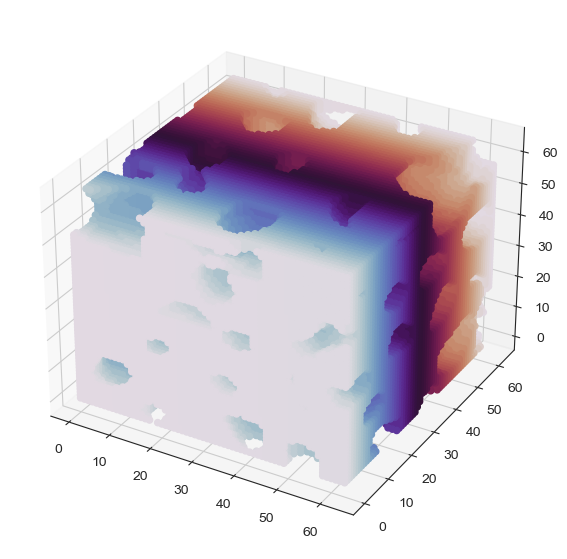

In [113]:
select_idx = optimization_ds["young_module"] == 2095.45232623
w = x_opt[select_idx]
generate(net_M, net_G, w[0], None, "w")

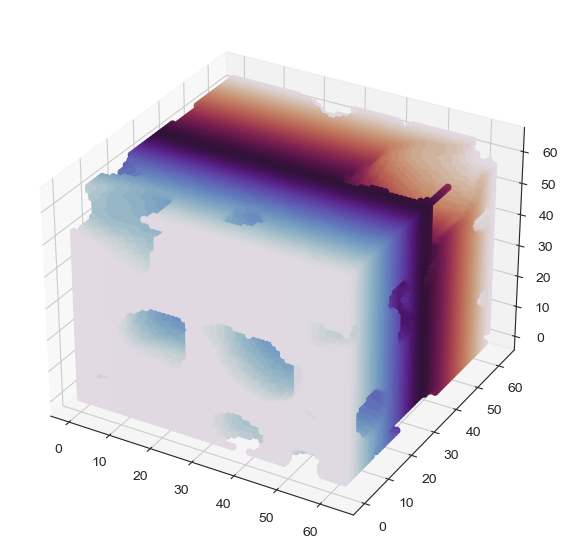

In [104]:
select_idx = optimization_ds["young_module"] == 2287.57643962
w = x_opt[select_idx]
generate(net_M, net_G, w[0], None, "w")

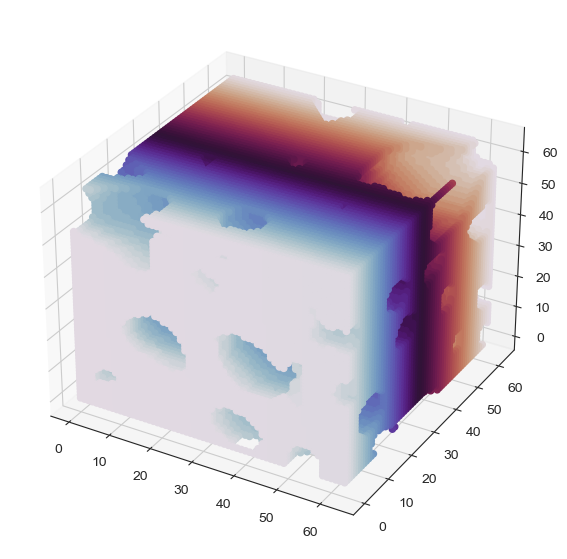

In [105]:
select_idx = optimization_ds["young_module"] == 2192.92985617
w = x_opt[select_idx]
generate(net_M, net_G, w[0], None, "w")

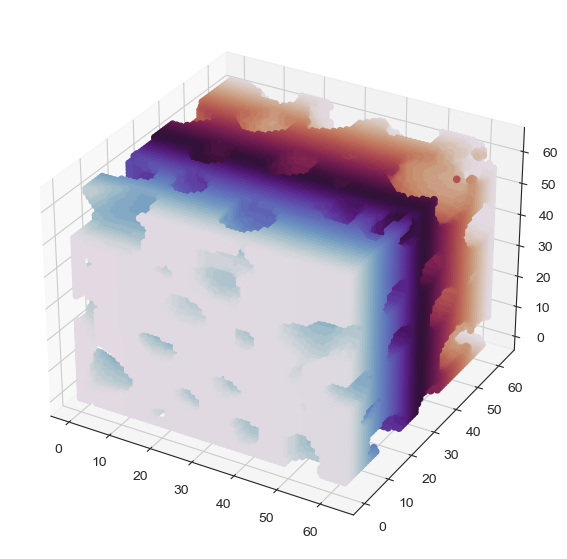

In [106]:
select_idx = optimization_ds["young_module"] == 1949.76964379
w = x_opt[select_idx]
generate(net_M, net_G, w[0], None, "w")

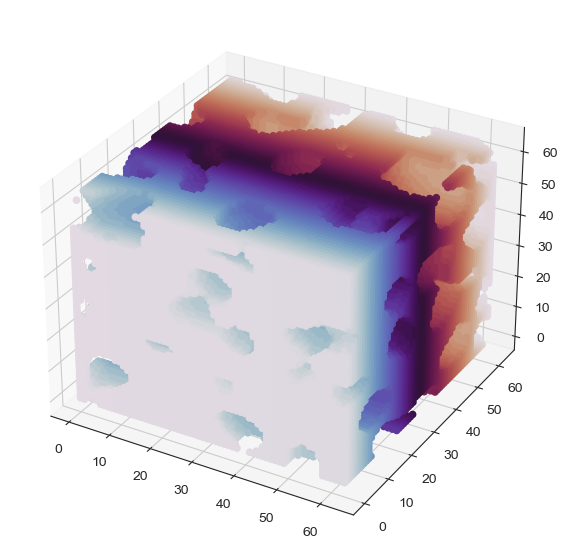

In [107]:
select_idx = optimization_ds["young_module"] == 1890.72735098
w = x_opt[select_idx]
generate(net_M, net_G, w[0], None, "w")

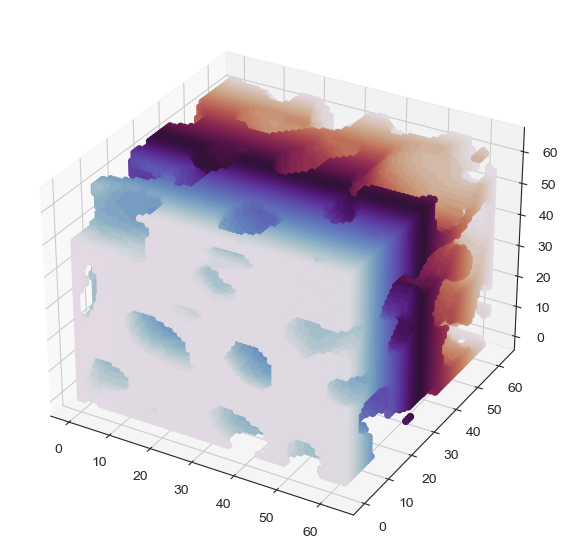

In [108]:
select_idx = optimization_ds["young_module"] == 1421.42731086
w = x_opt[select_idx]
generate(net_M, net_G, w[0], None, "w")

In [52]:
# Интересно взять точку с кластера, построить микроструктуру и сравнить их с другими кластерами
# Выдвигаю гипотезу, что 
fig = px.scatter(
    x=umap_embedding[:, 0],
    y=umap_embedding[:, 1],
    color=optimization_ds["young_module"]
)
fig.show()
#fig.colorbar(img, ax=ax, label="$f_2$, MPa", orientation="horizontal")

In [76]:
umap_embedding[:, 0]

array([-0.85728246,  3.3908765 ,  0.80029136, -1.6604881 ,  6.1475396 ,
        1.2102867 , -0.14620487, -0.26785493,  0.6733651 ,  4.145643  ,
        0.80712354, -1.5533078 ,  1.0323243 ,  2.841183  ,  0.6166608 ,
        3.1017194 ,  1.431317  , -0.3750979 ,  2.777858  ,  0.5099907 ,
       -2.2830083 , -0.97134584,  3.9927127 ,  1.1270673 ,  3.851955  ,
        2.8891306 , -2.347392  ,  2.7078884 ,  4.8802524 ,  4.036566  ,
        4.752139  , -1.4328389 , -1.7660148 , -0.6601607 ,  4.181556  ,
        0.9434901 ,  1.3045188 ,  2.322129  , -2.5565188 ,  5.9853134 ,
        5.4104376 ,  4.447075  ,  4.0976496 , -2.6919825 , -1.9954717 ,
        2.9569082 ,  3.8519218 ,  4.1425014 , -0.5403432 , -1.116362  ,
        3.7632577 ,  2.1289594 ,  6.0685205 ,  3.8753088 ,  0.8565849 ,
        0.9629145 ,  0.7497961 ,  5.7188683 ,  4.8807707 ,  0.5689046 ,
       -2.5016658 ,  4.3973327 ,  1.5780311 ,  3.2786717 ,  2.8269289 ,
        6.18583   ,  1.1728332 ,  6.2191634 ,  0.6359435 ,  2.64

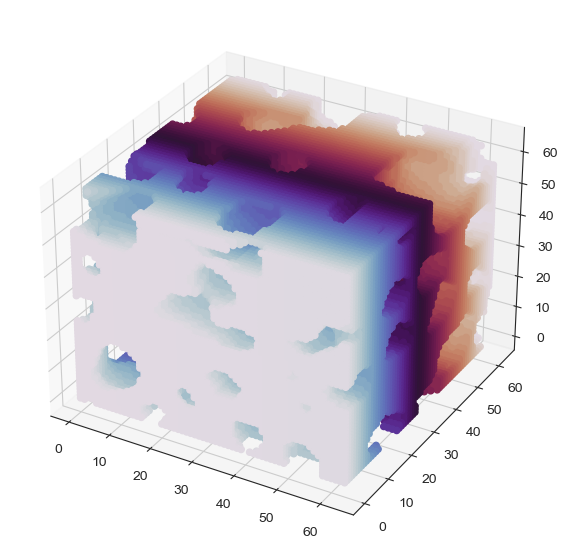

In [89]:
select_idx = umap_embedding[:, 0] == -0.97134584
w = x_opt[select_idx]

generate(net_M, net_G, w[0], None, "w")

# Pymoo test

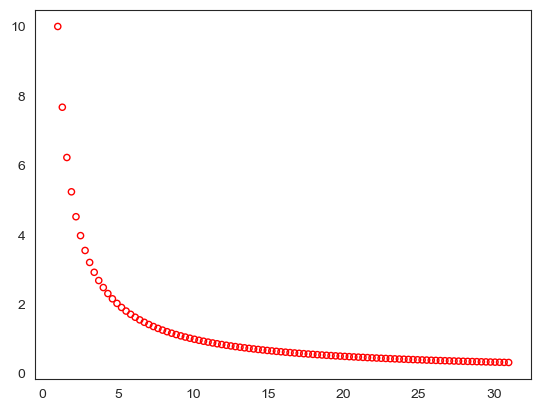

In [23]:
from pymoo.problems import get_problem
from pymoo.util.plotting import plot

problem = get_problem("zdt5", normalize=False)
plot(problem.pareto_front(), no_fill=True)

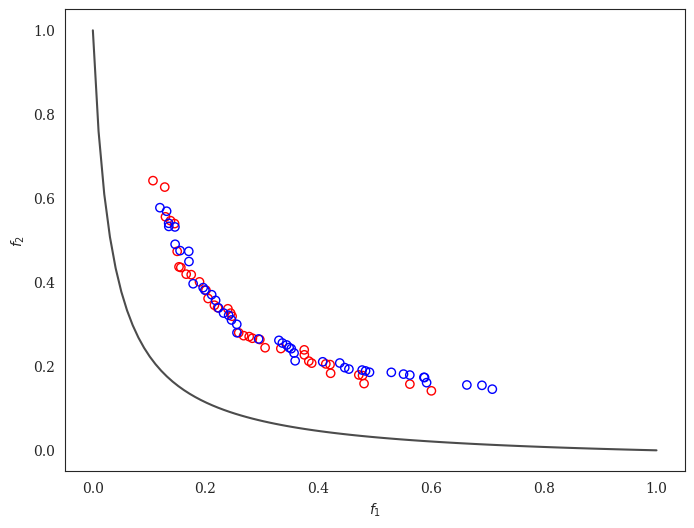

In [24]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.problems import get_problem
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter
from pymoo.operators.sampling.lhs import LHS
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PolynomialMutation as PM

problem = get_problem("zdt5")

algorithm = NSGA2(
    pop_size=100,
    sampling=LHS(iterations=1000),
    crossover=SBX(eta=5, prob=0.9),
    mutation=PM(eta=2)
)

res = minimize(problem,
               algorithm,
               ('n_gen', 10),
               seed=1,
               verbose=False)

algorithm = NSGA2(
    pop_size=100,
    sampling=LHS(iterations=1000),
    crossover=SBX(eta=5, prob=0.9),
    mutation=PM(eta=20)
)

res2 = minimize(problem,
               algorithm,
               ('n_gen', 10),
               seed=1,
               verbose=False)

plot = Scatter()
plot.add(problem.pareto_front(), plot_type="line", color="black", alpha=0.7)
plot.add(res.F, facecolor="none", edgecolor="red")
plot.add(res2.F, facecolor="none", edgecolor="blue")
plot.show()

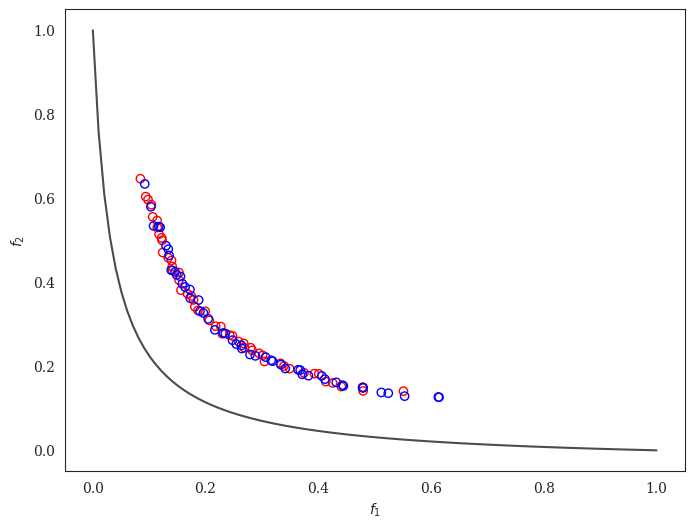

In [42]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.problems import get_problem
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter
from pymoo.operators.sampling.lhs import LHS
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PolynomialMutation as PM

problem = get_problem("zdt5")

algorithm = NSGA2(
    pop_size=50,
    sampling=LHS(iterations=1000),
    crossover=SBX(eta=5, prob=0.9),
    mutation=PM(eta=2)
)

res = minimize(problem,
               algorithm,
               ('n_gen', 20),
               seed=1,
               verbose=False)

algorithm = NSGA2(
    pop_size=50,
    sampling=LHS(iterations=1000),
    crossover=SBX(eta=5, prob=0.9),
    mutation=PM(eta=20)
)

res2 = minimize(problem,
               algorithm,
               ('n_gen', 20),
               seed=1,
               verbose=False)

plot = Scatter()
plot.add(problem.pareto_front(), plot_type="line", color="black", alpha=0.7)
plot.add(res.F, facecolor="none", edgecolor="red")
plot.add(res2.F, facecolor="none", edgecolor="blue")
plot.show()